In [12]:
# Cell 0: Manually set the correct project path
import os
from pathlib import Path

# MANUALLY SET YOUR PROJECT PATH - CHANGE THIS TO YOUR ACTUAL PATH
# Your project is at: C:\Users\nyvra\Downloads\sp500-predictor
PROJECT_PATH = Path(r"C:\Users\nyvra\Downloads\sp500-predictor")

# Change working directory to project root
os.chdir(PROJECT_PATH)

print(f"✅ Working directory changed to: {Path.cwd()}")
print(f"📁 Project exists: {Path.cwd().exists()}")

# Verify key directories exist
models_dir = Path.cwd() / 'models' / 'ensembles'
data_dir = Path.cwd() / 'data' / 'features'

print(f"\n🔍 Verification:")
print(f"   Models directory exists: {models_dir.exists()}")
print(f"   Data directory exists: {data_dir.exists()}")

if models_dir.exists():
    print(f"   Models found: {list(models_dir.glob('*.pkl'))}")
if data_dir.exists():
    print(f"   Data found: {list(data_dir.glob('*.parquet'))}")

✅ Working directory changed to: C:\Users\nyvra\Downloads\sp500-predictor
📁 Project exists: True

🔍 Verification:
   Models directory exists: True
   Data directory exists: True
   Models found: [WindowsPath('C:/Users/nyvra/Downloads/sp500-predictor/models/ensembles/final_model.pkl'), WindowsPath('C:/Users/nyvra/Downloads/sp500-predictor/models/ensembles/pca_imputer.pkl'), WindowsPath('C:/Users/nyvra/Downloads/sp500-predictor/models/ensembles/pca_model.pkl'), WindowsPath('C:/Users/nyvra/Downloads/sp500-predictor/models/ensembles/pca_scaler.pkl')]
   Data found: [WindowsPath('C:/Users/nyvra/Downloads/sp500-predictor/data/features/final_features.parquet')]


In [15]:
# Cell 1: Setup and Path Configuration
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

import shap

# Set working directory to project root
PROJECT_ROOT = Path(r"C:\Users\nyvra\Downloads\sp500-predictor")
os.chdir(PROJECT_ROOT)

# Define global paths
MODELS_PATH = PROJECT_ROOT / 'models' / 'ensembles'
DATA_PATH = PROJECT_ROOT / 'data' / 'features' / 'final_features.parquet'
SHAP_PATH = PROJECT_ROOT / 'visualizations' / 'plots'
SHAP_PATH.mkdir(parents=True, exist_ok=True)

print(f"✅ Working directory: {Path.cwd()}")
print(f"📁 Models path: {MODELS_PATH}")
print(f"📁 Data path: {DATA_PATH}")
print(f"📁 Output path: {SHAP_PATH}")
print(f"✅ SHAP analysis ready")

✅ Working directory: C:\Users\nyvra\Downloads\sp500-predictor
📁 Models path: C:\Users\nyvra\Downloads\sp500-predictor\models\ensembles
📁 Data path: C:\Users\nyvra\Downloads\sp500-predictor\data\features\final_features.parquet
📁 Output path: C:\Users\nyvra\Downloads\sp500-predictor\visualizations\plots
✅ SHAP analysis ready


In [16]:
# Cell 2: Load Model and Data
def load_model_and_data():
    """Load final model and test data"""
    print("📊 Loading model and data...")
    
    # Use global MODELS_PATH
    global MODELS_PATH, DATA_PATH
    
    # Check if model exists
    model_file = MODELS_PATH / 'final_model.pkl'
    
    if not model_file.exists():
        print(f"❌ Model not found at: {model_file}")
        
        # List what's in the models directory
        if MODELS_PATH.exists():
            print(f"\n📁 Files in {MODELS_PATH}:")
            for f in MODELS_PATH.iterdir():
                print(f"   - {f.name}")
        else:
            print(f"❌ Models directory not found: {MODELS_PATH}")
        
        raise FileNotFoundError(f"Model not found at {model_file}")
    
    # Load final model
    with open(model_file, 'rb') as f:
        model = pickle.load(f)
    print(f"✅ Loaded model: {type(model).__name__}")
    
    # Load features
    if not DATA_PATH.exists():
        raise FileNotFoundError(f"Data not found at: {DATA_PATH}")
    
    df = pd.read_parquet(DATA_PATH)
    feature_cols = [col for col in df.columns if col != 'target_next_week']
    X = df[feature_cols].values
    y = df['target_next_week'].values
    feature_names = feature_cols
    
    # Use test set (last 20%)
    split_idx = int(len(X) * 0.8)
    X_test = X[split_idx:]
    y_test = y[split_idx:]
    
    print(f"✅ Test data: {X_test.shape[0]} samples, {X_test.shape[1]} features")
    
    return model, X_test, y_test, feature_names

# Load data
model, X_test, y_test, feature_names = load_model_and_data()

📊 Loading model and data...
✅ Loaded model: Pipeline
✅ Test data: 818 samples, 44 features


In [17]:
# Cell 3: Extract Regressor from Pipeline
def extract_regressor(pipeline):
    """Extract the actual model from pipeline"""
    if hasattr(pipeline, 'named_steps'):
        # Get the last step (the actual model)
        last_step = list(pipeline.named_steps.keys())[-1]
        return pipeline.named_steps[last_step]
    return pipeline

# Extract the actual model
base_model = extract_regressor(model)
print(f"📊 Extracted model: {type(base_model).__name__}")

📊 Extracted model: CatBoostRegressor


In [18]:
# Cell 4: Create SHAP Explainer
print("\n🔍 Creating SHAP explainer...")

# Use a subset for faster computation
n_samples = min(100, X_test.shape[0])
X_sample = X_test[:n_samples]

# Use TreeExplainer for tree-based models
model_type = str(type(base_model)).lower()

if 'catboost' in model_type:
    explainer = shap.TreeExplainer(base_model)
    shap_values = explainer.shap_values(X_sample)
    print("✅ Using TreeExplainer for CatBoost")
elif 'xgb' in model_type:
    explainer = shap.TreeExplainer(base_model)
    shap_values = explainer.shap_values(X_sample)
    print("✅ Using TreeExplainer for XGBoost")
elif 'lgbm' in model_type or 'lightgbm' in model_type:
    explainer = shap.TreeExplainer(base_model)
    shap_values = explainer.shap_values(X_sample)
    print("✅ Using TreeExplainer for LightGBM")
else:
    # For other models, use KernelExplainer
    print("⚠️ Using KernelExplainer (slower, using subset)")
    background = shap.kmeans(X_sample, 50)
    explainer = shap.KernelExplainer(base_model.predict, background)
    shap_values = explainer.shap_values(X_sample)
    print("✅ Using KernelExplainer")

print(f"✅ SHAP values calculated")


🔍 Creating SHAP explainer...
✅ Using TreeExplainer for CatBoost
✅ SHAP values calculated



📊 Creating SHAP summary plot...


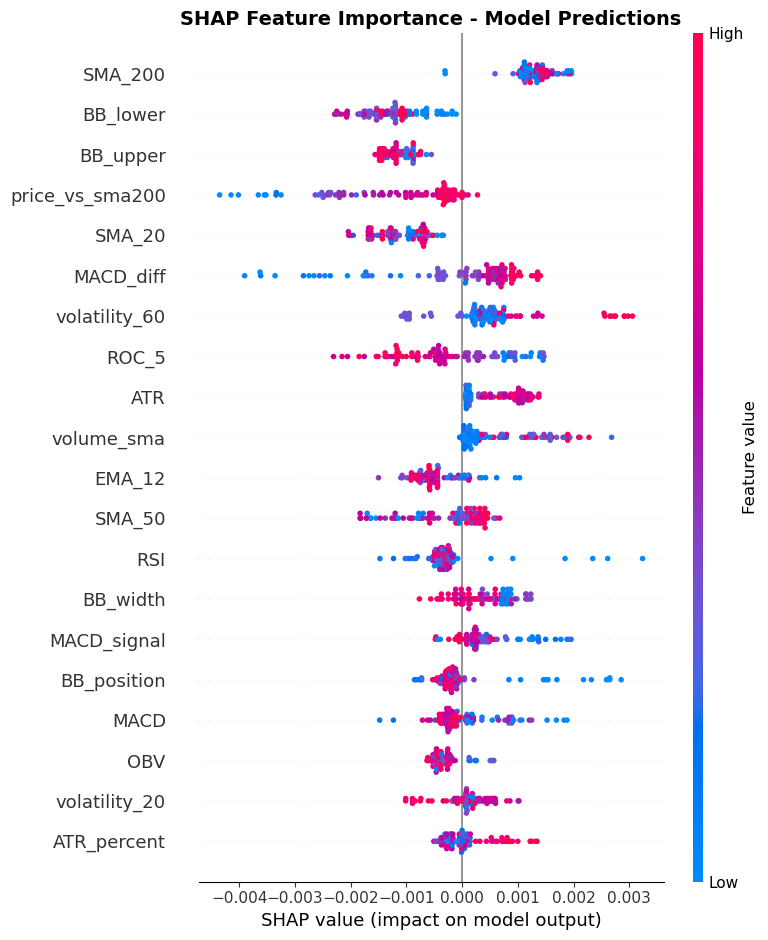

✅ Saved: C:\Users\nyvra\Downloads\sp500-predictor\visualizations\plots\shap_summary.png


In [19]:
# Cell 5: SHAP Summary Plot
print("\n📊 Creating SHAP summary plot...")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance - Model Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SHAP_PATH / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {SHAP_PATH / 'shap_summary.png'}")

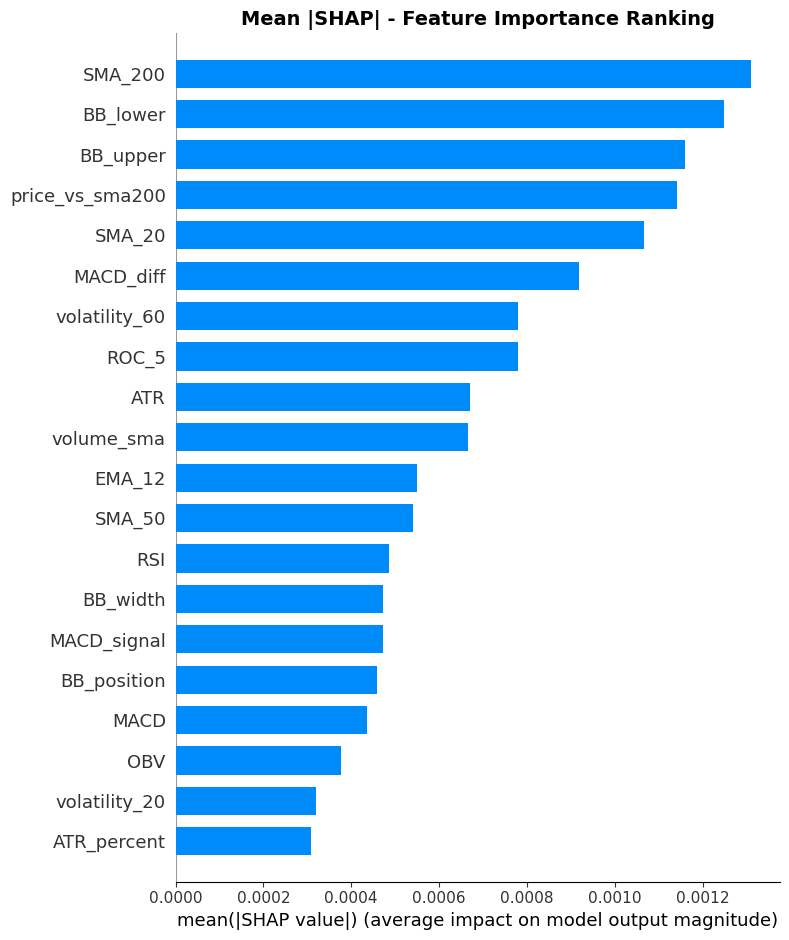

✅ Saved: C:\Users\nyvra\Downloads\sp500-predictor\visualizations\plots\shap_bar.png


In [20]:
# Cell 6: SHAP Bar Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, 
                  plot_type="bar", show=False)
plt.title('Mean |SHAP| - Feature Importance Ranking', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SHAP_PATH / 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {SHAP_PATH / 'shap_bar.png'}")

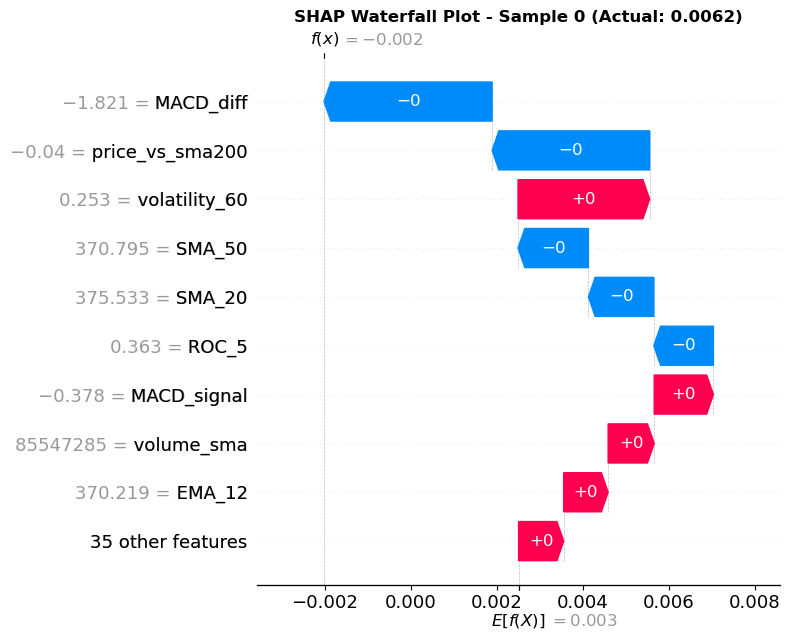

✅ Saved waterfall for sample 0


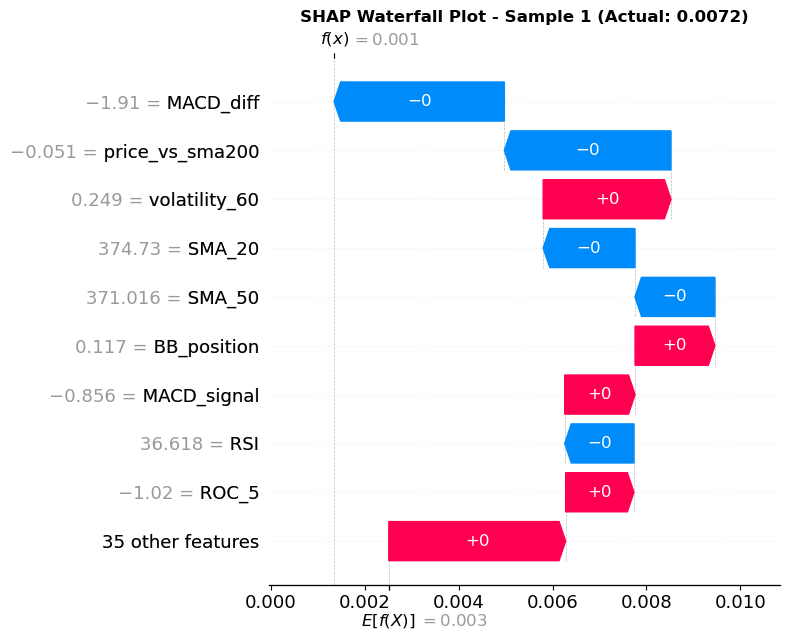

✅ Saved waterfall for sample 1


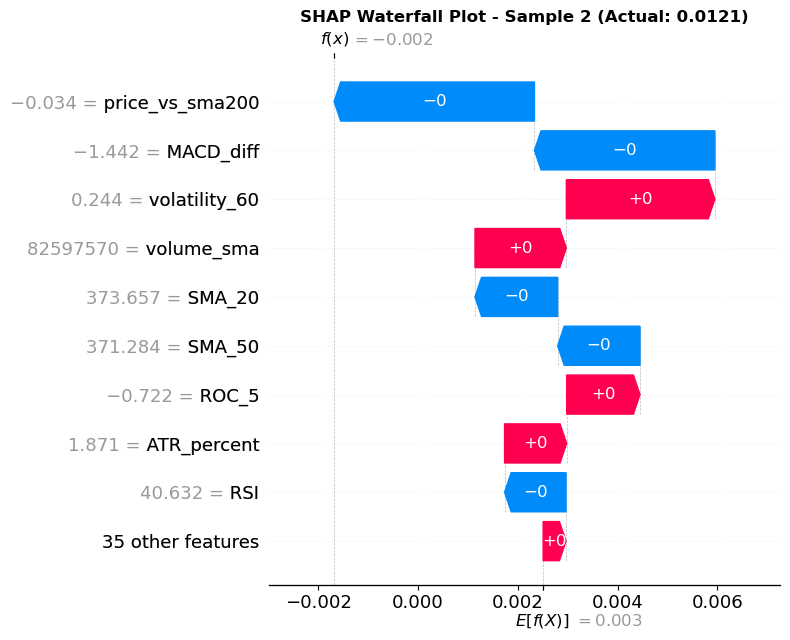

✅ Saved waterfall for sample 2


In [21]:
# Cell 7: Waterfall Plots for Individual Predictions
def plot_waterfall_for_sample(sample_idx=0):
    """Create waterfall plot for a single prediction"""
    try:
        plt.figure(figsize=(10, 6))
        
        # Get expected value
        if hasattr(explainer, 'expected_value'):
            expected_value = explainer.expected_value
        else:
            expected_value = 0
        
        # Handle different shap_values formats
        if len(shap_values.shape) == 3:
            sv = shap_values[sample_idx, :, 0]
        elif len(shap_values.shape) == 2:
            sv = shap_values[sample_idx]
        else:
            sv = shap_values[sample_idx]
        
        shap.waterfall_plot(
            shap.Explanation(
                values=sv,
                base_values=expected_value if not isinstance(expected_value, np.ndarray) else expected_value[0],
                data=X_sample[sample_idx],
                feature_names=feature_names
            ),
            show=False,
            max_display=10
        )
        plt.title(f'SHAP Waterfall Plot - Sample {sample_idx} (Actual: {y_test[sample_idx]:.4f})', 
                  fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(SHAP_PATH / f'shap_waterfall_sample_{sample_idx}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved waterfall for sample {sample_idx}")
    except Exception as e:
        print(f"⚠️ Could not create waterfall plot: {e}")

# Plot waterfall for first 3 samples
for i in range(min(3, X_sample.shape[0])):
    plot_waterfall_for_sample(i)

In [22]:
# Cell 8: Summary
print("\n" + "="*60)
print("✅ SHAP Analysis Complete!")
print("="*60)
print(f"\n📁 Output files saved to: {SHAP_PATH}")
print(f"   - shap_summary.png")
print(f"   - shap_bar.png")
print(f"   - shap_waterfall_sample_*.png")
print(f"\n📊 Model Info:")
print(f"   - Model type: {type(base_model).__name__}")
print(f"   - Test samples: {X_test.shape[0]}")
print(f"   - Features: {X_test.shape[1]}")
print(f"   - SHAP samples used: {X_sample.shape[0]}")


✅ SHAP Analysis Complete!

📁 Output files saved to: C:\Users\nyvra\Downloads\sp500-predictor\visualizations\plots
   - shap_summary.png
   - shap_bar.png
   - shap_waterfall_sample_*.png

📊 Model Info:
   - Model type: CatBoostRegressor
   - Test samples: 818
   - Features: 44
   - SHAP samples used: 100
